# Day 3 — Robustness and Strategy Search

The goal of this notebook is not to celebrate one attractive chart. It is to test whether the Day 3 result survives seed changes and whether small, course-compatible changes to features and network size can produce a stronger real portfolio.


## Search Scope

Only repository-native tools are used here:

- the existing EGX `DataFeed`
- Week 1 indicators already present in `src/tradinglab/indicators.py`
- the repository `MLP`, `DeepMLP`, and `LSTMRegressor`
- the shared `train_model` and `PortfolioSimulator`

No external data, packages, or APIs are introduced.


In [1]:
from pathlib import Path
import os
import sys
from textwrap import dedent

repo_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "src" / "tradinglab").exists()
)
os.chdir(repo_root)

tmp_dir = repo_root / ".tmp"
(tmp_dir / "matplotlib").mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(tmp_dir / "matplotlib"))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

src_path = str(repo_root / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from tradinglab.data_feed import DataFeed
from tradinglab.day3 import (
    ALL_FEATURES,
    BASELINE_FEATURES,
    aggregate_run_metrics,
    build_dashboard_artifact,
    build_feature_tensor,
    run_shared_model_portfolio,
    save_dashboard_artifact,
)


In [2]:
feed = DataFeed.from_dir("data/egx")
split_day = int(feed.n_days * 0.7)
lookback = 30
seeds = [1, 7, 42, 123, 2026]

feature_sets = {
    "baseline": BASELINE_FEATURES,
    "momentum": BASELINE_FEATURES + ("return_5d", "return_10d"),
    "full": ALL_FEATURES,
}
feature_tensors = {
    name: build_feature_tensor(feed, features)
    for name, features in feature_sets.items()
}

baseline_mlp = {
    "name": "mlp_baseline",
    "model_type": "mlp",
    "feature_set": "baseline",
    "hidden": 32,
    "n_hidden_layers": 1,
    "epochs": 150,
    "lr": 1e-3,
}
baseline_lstm = {
    "name": "lstm_baseline",
    "model_type": "lstm",
    "feature_set": "baseline",
    "hidden": 32,
    "seq_len": 10,
    "epochs": 150,
    "lr": 1e-3,
}

mlp_candidates = [
    baseline_mlp,
    {
        "name": "mlp_wide",
        "model_type": "mlp",
        "feature_set": "baseline",
        "hidden": 64,
        "n_hidden_layers": 1,
        "epochs": 200,
        "lr": 1e-3,
    },
    {
        "name": "mlp_deep",
        "model_type": "mlp",
        "feature_set": "baseline",
        "hidden": 32,
        "n_hidden_layers": 2,
        "epochs": 200,
        "lr": 5e-4,
    },
    {
        "name": "mlp_momentum",
        "model_type": "mlp",
        "feature_set": "momentum",
        "hidden": 64,
        "n_hidden_layers": 1,
        "epochs": 200,
        "lr": 1e-3,
    },
    {
        "name": "mlp_full",
        "model_type": "mlp",
        "feature_set": "full",
        "hidden": 64,
        "n_hidden_layers": 2,
        "epochs": 200,
        "lr": 5e-4,
    },
]

lstm_candidates = [
    baseline_lstm,
    {
        "name": "lstm_seq5",
        "model_type": "lstm",
        "feature_set": "baseline",
        "hidden": 32,
        "seq_len": 5,
        "epochs": 150,
        "lr": 1e-3,
    },
    {
        "name": "lstm_wide",
        "model_type": "lstm",
        "feature_set": "baseline",
        "hidden": 64,
        "seq_len": 10,
        "epochs": 200,
        "lr": 1e-3,
    },
    {
        "name": "lstm_momentum",
        "model_type": "lstm",
        "feature_set": "momentum",
        "hidden": 64,
        "seq_len": 5,
        "epochs": 200,
        "lr": 1e-3,
    },
    {
        "name": "lstm_full",
        "model_type": "lstm",
        "feature_set": "full",
        "hidden": 64,
        "seq_len": 10,
        "epochs": 200,
        "lr": 5e-4,
    },
]

candidate_by_name = {
    candidate["name"]: candidate
    for candidate in [*mlp_candidates, *lstm_candidates]
}

def run_candidate(candidate, seed):
    kwargs = dict(
        feature_names=feature_sets[candidate["feature_set"]],
        feature_tensor=feature_tensors[candidate["feature_set"]],
        lookback=lookback,
        hidden=candidate["hidden"],
        epochs=candidate["epochs"],
        lr=candidate["lr"],
        seed=seed,
        commission=0.0,
    )
    if candidate["model_type"] == "mlp":
        kwargs["n_hidden_layers"] = candidate.get("n_hidden_layers", 1)
    else:
        kwargs["seq_len"] = candidate["seq_len"]
    return run_shared_model_portfolio(feed, candidate["model_type"], **kwargs)

def run_seed_sweep(candidate, seeds_to_run):
    rows = []
    runs = []
    for seed in seeds_to_run:
        run = run_candidate(candidate, seed)
        runs.append(run)
        metrics = run["result"]["metrics"]
        prediction_metrics = run["result"]["prediction_metrics"]
        rows.append(
            {
                "candidate": candidate["name"],
                "model_type": candidate["model_type"],
                "feature_set": candidate["feature_set"],
                "hidden": candidate["hidden"],
                "n_hidden_layers": candidate.get("n_hidden_layers"),
                "seq_len": candidate.get("seq_len"),
                "epochs": candidate["epochs"],
                "lr": candidate["lr"],
                "seed": seed,
                "total_return": metrics["total_return"],
                "sharpe": metrics["sharpe"],
                "max_drawdown": metrics["max_drawdown"],
                "excess_return": metrics["excess_return"],
                "final_value": metrics["final_value"],
                "benchmark_final_value": metrics["benchmark_final_value"],
                "benchmark_return": metrics["benchmark_return"],
                "average_stocks_held": metrics["average_stocks_held"],
                "test_mse": prediction_metrics["test_mse"],
                "information_coefficient": prediction_metrics["information_coefficient"],
            }
        )
    summary = aggregate_run_metrics(runs)
    return rows, summary, runs


In [3]:
baseline_rows = []
baseline_summary_rows = []
baseline_runs = {}

for candidate in [baseline_mlp, baseline_lstm]:
    rows, summary, runs = run_seed_sweep(candidate, seeds)
    baseline_rows.extend(rows)
    baseline_runs[candidate["name"]] = runs
    baseline_summary_rows.append(
        {
            "candidate": candidate["name"],
            "model_type": candidate["model_type"],
            "mean_total_return": summary["mean_total_return"],
            "std_total_return": summary["std_total_return"],
            "mean_sharpe": summary["mean_sharpe"],
            "mean_max_drawdown": summary["mean_max_drawdown"],
            "mean_excess_return": summary["mean_excess_return"],
            "beat_benchmark_count": summary["beat_benchmark_count"],
            "beat_benchmark_pct": summary["beat_benchmark_pct"],
            "best_seed": summary["best_seed"],
            "worst_seed": summary["worst_seed"],
        }
    )

baseline_seed_table = pd.DataFrame(baseline_rows)
baseline_summary = pd.DataFrame(baseline_summary_rows).set_index("candidate")

display(Markdown("## Baseline Seed Sweep"))
display(baseline_seed_table)
display(Markdown("## Baseline Seed Robustness Summary"))
baseline_summary


## Baseline Seed Sweep

,candidate,model_type,feature_set,hidden,n_hidden_layers,seq_len,epochs,lr,seed,total_return,sharpe,max_drawdown,excess_return,final_value,benchmark_final_value,benchmark_return,average_stocks_held,test_mse,information_coefficient
0,mlp_baseline,mlp,baseline,32,1.0,NaN,150,0.001,1,0.573133,2.082623,0.089816,0.005935,1.573133,1.567198,0.567198,27.968300,0.000580,0.025738
1,mlp_baseline,mlp,baseline,32,1.0,NaN,150,0.001,7,0.631134,2.248887,0.093942,0.063937,1.631134,1.567198,0.567198,27.832853,0.000581,0.009643
2,mlp_baseline,mlp,baseline,32,1.0,NaN,150,0.001,42,0.497437,1.908623,0.086224,-0.069760,1.497437,1.567198,0.567198,28.579251,0.000588,-0.010810
3,mlp_baseline,mlp,baseline,32,1.0,NaN,150,0.001,123,0.559637,2.124496,0.097076,-0.007561,1.559637,1.567198,0.567198,28.363112,0.000579,0.018579
4,mlp_baseline,mlp,baseline,32,1.0,NaN,150,0.001,2026,0.550988,2.083596,0.098154,-0.016209,1.550988,1.567198,0.567198,29.985591,0.000579,0.026689
5,lstm_baseline,lstm,baseline,32,NaN,10.0,150,0.001,1,0.560457,2.112951,0.083769,-0.006741,1.560457,1.567198,0.567198,33.763689,0.000587,-0.004633
6,lstm_baseline,lstm,baseline,32,NaN,10.0,150,0.001,7,0.611548,2.191382,0.079020,0.044350,1.611548,1.567198,0.567198,31.974063,0.000588,0.008606
7,lstm_baseline,lstm,baseline,32,NaN,10.0,150,0.001,42,0.560949,2.114230,0.076062,-0.006249,1.560949,1.567198,0.567198,33.902017,0.000586,-0.003607
8,lstm_baseline,lstm,baseline,32,NaN,10.0,150,0.001,123,0.568273,2.135328,0.077052,0.001076,1.568273,1.567198,0.567198,33.976945,0.000587,-0.016785
9,lstm_baseline,lstm,baseline,32,NaN,10.0,150,0.001,2026,0.564470,2.096411,0.080931,-0.002727,1.564470,1.567198,0.567198,32.207493,0.000588,-0.015298


## Baseline Seed Robustness Summary

,model_type,mean_total_return,std_total_return,mean_sharpe,mean_max_drawdown,mean_excess_return,beat_benchmark_count,beat_benchmark_pct,best_seed,worst_seed
candidate,,,,,,,,,,
mlp_baseline,mlp,0.562466,0.042890,2.089645,0.093043,-0.004732,2,0.4,7,42
lstm_baseline,lstm,0.573139,0.019409,2.130061,0.079367,0.005942,2,0.4,7,1


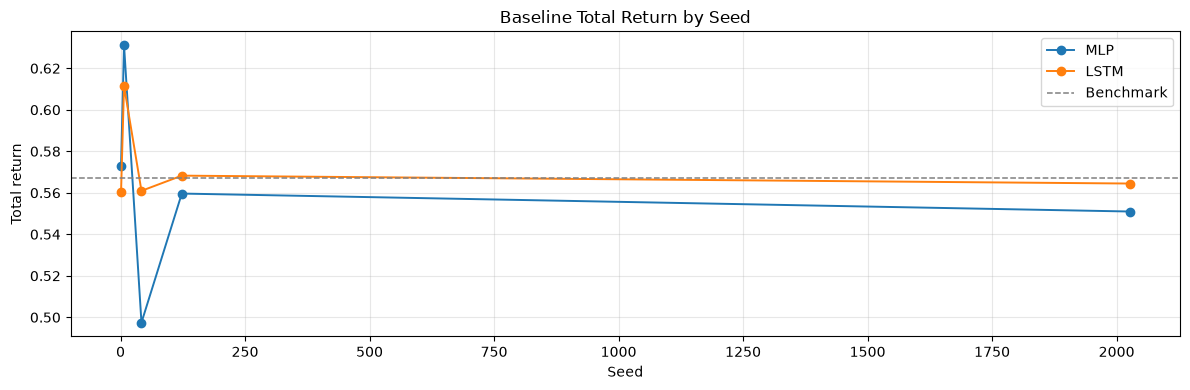

In [4]:
benchmark_reference = float(baseline_seed_table["benchmark_return"].iloc[0])

plt.figure(figsize=(12, 4))
for candidate_name, label in [("mlp_baseline", "MLP"), ("lstm_baseline", "LSTM")]:
    subset = baseline_seed_table[baseline_seed_table["candidate"] == candidate_name].sort_values("seed")
    plt.plot(subset["seed"], subset["total_return"], marker="o", linewidth=1.4, label=label)
plt.axhline(benchmark_reference, color="gray", linestyle="--", linewidth=1.1, label="Benchmark")
plt.title("Baseline Total Return by Seed")
plt.xlabel("Seed")
plt.ylabel("Total return")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [5]:
mlp_base_summary = baseline_summary.loc["mlp_baseline"]
lstm_base_summary = baseline_summary.loc["lstm_baseline"]

sensitivity_text = f'''
## Seed Robustness Interpretation

- Does performance remain similar across seeds? **Not really for the baseline MLP**. Its mean total return across the changed seeds is `{mlp_base_summary["mean_total_return"]:.2%}` with a standard deviation of `{mlp_base_summary["std_total_return"]:.2%}`, and it only beat the benchmark in `{int(mlp_base_summary["beat_benchmark_count"])}/{len(seeds)}` runs.
- Does one model appear highly seed-dependent? **Yes: the baseline MLP is more seed-sensitive**. The baseline LSTM is more stable numerically (`{lstm_base_summary["std_total_return"]:.2%}` standard deviation) but mostly because it behaves very similarly to the benchmark.
- Did the original result appear lucky? **Partly yes**. The seed-0 baseline chart looked acceptable, but the changed-seed sweep shows that neither baseline model beats the benchmark consistently enough to treat one run as proof.
- Which model is more stable? **The baseline LSTM** is more stable by return dispersion, but **the baseline MLP** still reaches the better upside when it works.
'''
display(Markdown(dedent(sensitivity_text).strip()))


## Seed Robustness Interpretation

- Does performance remain similar across seeds? **Not really for the baseline MLP**. Its mean total return across the changed seeds is `56.25%` with a standard deviation of `4.29%`, and it only beat the benchmark in `2/5` runs.
- Does one model appear highly seed-dependent? **Yes: the baseline MLP is more seed-sensitive**. The baseline LSTM is more stable numerically (`1.94%` standard deviation) but mostly because it behaves very similarly to the benchmark.
- Did the original result appear lucky? **Partly yes**. The seed-0 baseline chart looked acceptable, but the changed-seed sweep shows that neither baseline model beats the benchmark consistently enough to treat one run as proof.
- Which model is more stable? **The baseline LSTM** is more stable by return dispersion, but **the baseline MLP** still reaches the better upside when it works.

In [6]:
seed0_rows = []
for candidate in [*mlp_candidates, *lstm_candidates]:
    run = run_candidate(candidate, seed=0)
    metrics = run["result"]["metrics"]
    prediction_metrics = run["result"]["prediction_metrics"]
    seed0_rows.append(
        {
            "candidate": candidate["name"],
            "model_type": candidate["model_type"],
            "feature_set": candidate["feature_set"],
            "hidden": candidate["hidden"],
            "n_hidden_layers": candidate.get("n_hidden_layers"),
            "seq_len": candidate.get("seq_len"),
            "epochs": candidate["epochs"],
            "lr": candidate["lr"],
            "test_mse": prediction_metrics["test_mse"],
            "information_coefficient": prediction_metrics["information_coefficient"],
            "total_return": metrics["total_return"],
            "sharpe": metrics["sharpe"],
            "max_drawdown": metrics["max_drawdown"],
            "excess_return": metrics["excess_return"],
            "average_stocks_held": metrics["average_stocks_held"],
        }
    )

seed0_results = pd.DataFrame(seed0_rows).sort_values(
    by=["excess_return", "sharpe", "total_return"],
    ascending=[False, False, False],
)

tested_sets_text = '''
## Configurations Tested

- Feature sets tested: `baseline`, `momentum = baseline + return_5d + return_10d`, and `full = all repository Week 2 features`
- MLP architectures tested: hidden size `32`, hidden size `64`, and `DeepMLP` with `2` hidden layers
- LSTM configurations tested: sequence length `5` and `10`, hidden size `32` and `64`
- Learning rates / epochs tested: `1e-3` with `150` or `200` epochs, and `5e-4` with `200` epochs
'''
display(Markdown(dedent(tested_sets_text).strip()))
seed0_results


## Configurations Tested

- Feature sets tested: `baseline`, `momentum = baseline + return_5d + return_10d`, and `full = all repository Week 2 features`
- MLP architectures tested: hidden size `32`, hidden size `64`, and `DeepMLP` with `2` hidden layers
- LSTM configurations tested: sequence length `5` and `10`, hidden size `32` and `64`
- Learning rates / epochs tested: `1e-3` with `150` or `200` epochs, and `5e-4` with `200` epochs

,candidate,model_type,feature_set,hidden,n_hidden_layers,seq_len,epochs,lr,test_mse,information_coefficient,total_return,sharpe,max_drawdown,excess_return,average_stocks_held
3,mlp_momentum,mlp,momentum,64,1.0,NaN,200,0.0010,0.000580,0.019569,0.648333,2.295419,0.093173,0.081135,25.129683
1,mlp_wide,mlp,baseline,64,1.0,NaN,200,0.0010,0.000578,0.025849,0.601824,2.226033,0.088077,0.034627,29.625360
0,mlp_baseline,mlp,baseline,32,1.0,NaN,150,0.0010,0.000582,-0.011368,0.573453,2.057016,0.086470,0.006256,30.668588
7,lstm_wide,lstm,baseline,64,NaN,10.0,200,0.0010,0.000587,-0.007631,0.572825,2.120483,0.077034,0.005627,33.144092
5,lstm_baseline,lstm,baseline,32,NaN,10.0,150,0.0010,0.000587,-0.007781,0.571768,2.144781,0.077753,0.004570,33.927954
6,lstm_seq5,lstm,baseline,32,NaN,5.0,150,0.0010,0.000581,-0.010775,0.567793,2.134638,0.078021,0.000596,33.956772
8,lstm_momentum,lstm,momentum,64,NaN,5.0,200,0.0010,0.000582,-0.019094,0.563377,2.119285,0.079344,-0.003821,33.824207
2,mlp_deep,mlp,baseline,32,2.0,NaN,200,0.0005,0.000586,-0.006017,0.544398,2.001011,0.104818,-0.022800,27.613833
9,lstm_full,lstm,full,64,NaN,10.0,200,0.0005,0.000612,-0.018907,0.533054,2.007356,0.087003,-0.034144,27.850144
4,mlp_full,mlp,full,64,2.0,NaN,200,0.0005,0.000610,-0.010775,0.526339,1.933016,0.093108,-0.040859,25.798271


In [7]:
shortlist_names = ["mlp_wide", "mlp_momentum", "lstm_baseline", "lstm_wide"]
shortlist_rows = []
shortlist_summary_rows = []
shortlist_runs = {}

for name in shortlist_names:
    candidate = candidate_by_name[name]
    rows, summary, runs = run_seed_sweep(candidate, seeds)
    shortlist_rows.extend(rows)
    shortlist_runs[name] = runs
    shortlist_summary_rows.append(
        {
            "candidate": name,
            "model_type": candidate["model_type"],
            "feature_set": candidate["feature_set"],
            "hidden": candidate["hidden"],
            "n_hidden_layers": candidate.get("n_hidden_layers"),
            "seq_len": candidate.get("seq_len"),
            "epochs": candidate["epochs"],
            "lr": candidate["lr"],
            "mean_total_return": summary["mean_total_return"],
            "std_total_return": summary["std_total_return"],
            "mean_sharpe": summary["mean_sharpe"],
            "mean_max_drawdown": summary["mean_max_drawdown"],
            "mean_excess_return": summary["mean_excess_return"],
            "beat_benchmark_count": summary["beat_benchmark_count"],
            "beat_benchmark_pct": summary["beat_benchmark_pct"],
            "best_seed": summary["best_seed"],
            "worst_seed": summary["worst_seed"],
        }
    )

shortlist_table = pd.DataFrame(shortlist_rows)
shortlist_summary = pd.DataFrame(shortlist_summary_rows).sort_values(
    by=["beat_benchmark_pct", "mean_sharpe", "mean_excess_return", "mean_max_drawdown"],
    ascending=[False, False, False, True],
).set_index("candidate")

display(Markdown("## Shortlisted Configurations Across Seeds"))
display(shortlist_table)
display(Markdown("## Robustness Comparison for the Shortlist"))
shortlist_summary


## Shortlisted Configurations Across Seeds

,candidate,model_type,feature_set,hidden,n_hidden_layers,seq_len,epochs,lr,seed,total_return,sharpe,max_drawdown,excess_return,final_value,benchmark_final_value,benchmark_return,average_stocks_held,test_mse,information_coefficient
0,mlp_wide,mlp,baseline,64,1.0,NaN,200,0.001,1,0.577402,2.181241,0.082587,0.010204,1.577402,1.567198,0.567198,31.126801,0.000579,0.025332
1,mlp_wide,mlp,baseline,64,1.0,NaN,200,0.001,7,0.514687,1.950674,0.091716,-0.052511,1.514687,1.567198,0.567198,25.884726,0.000582,0.001765
2,mlp_wide,mlp,baseline,64,1.0,NaN,200,0.001,42,0.675960,2.318419,0.085168,0.108763,1.675960,1.567198,0.567198,28.221902,0.000580,0.007967
3,mlp_wide,mlp,baseline,64,1.0,NaN,200,0.001,123,0.565712,2.097792,0.090995,-0.001486,1.565712,1.567198,0.567198,28.282421,0.000578,0.031449
4,mlp_wide,mlp,baseline,64,1.0,NaN,200,0.001,2026,0.641337,2.322681,0.095696,0.074139,1.641337,1.567198,0.567198,27.112392,0.000578,0.030762
5,mlp_momentum,mlp,momentum,64,1.0,NaN,200,0.001,1,0.599050,2.128731,0.087036,0.031853,1.599050,1.567198,0.567198,24.691643,0.000587,0.019313
6,mlp_momentum,mlp,momentum,64,1.0,NaN,200,0.001,7,0.652233,2.321630,0.091849,0.085035,1.652233,1.567198,0.567198,27.440922,0.000578,0.031214
7,mlp_momentum,mlp,momentum,64,1.0,NaN,200,0.001,42,0.754184,2.630402,0.087993,0.186986,1.754184,1.567198,0.567198,24.850144,0.000583,0.032917
8,mlp_momentum,mlp,momentum,64,1.0,NaN,200,0.001,123,0.526977,2.002972,0.093226,-0.040221,1.526977,1.567198,0.567198,28.446686,0.000583,0.009208
9,mlp_momentum,mlp,momentum,64,1.0,NaN,200,0.001,2026,0.635575,2.256354,0.091998,0.068377,1.635575,1.567198,0.567198,28.213256,0.000580,0.022852


## Robustness Comparison for the Shortlist

,model_type,feature_set,hidden,n_hidden_layers,seq_len,epochs,lr,mean_total_return,std_total_return,mean_sharpe,mean_max_drawdown,mean_excess_return,beat_benchmark_count,beat_benchmark_pct,best_seed,worst_seed
candidate,,,,,,,,,,,,,,,,
mlp_momentum,mlp,momentum,64,1.0,NaN,200,0.001,0.633604,0.074100,2.268018,0.090420,0.066406,4,0.8,42,123
mlp_wide,mlp,baseline,64,1.0,NaN,200,0.001,0.595020,0.057130,2.174161,0.089233,0.027822,3,0.6,42,7
lstm_baseline,lstm,baseline,32,NaN,10.0,150,0.001,0.573139,0.019409,2.130061,0.079367,0.005942,2,0.4,7,1
lstm_wide,lstm,baseline,64,NaN,10.0,200,0.001,0.566940,0.000784,2.127028,0.079561,-0.000258,2,0.4,123,7


In [8]:
best_candidate_name = shortlist_summary.index[0]
best_candidate = candidate_by_name[best_candidate_name]
best_seed_for_dashboard = 0
best_run = run_candidate(best_candidate, best_seed_for_dashboard)

best_artifact = build_dashboard_artifact(
    strategy_id="best_neural",
    strategy_name="Best Neural Strategy",
    strategy_description=(
        "Week 2 Day 3 best robust neural portfolio. Shared MLP across the full "
        "universe, equal weights across stocks with positive predicted returns."
    ),
    run=best_run,
)
save_dashboard_artifact("dashboard/data/best_neural_strategy.json", best_artifact)

best_summary = shortlist_summary.loc[best_candidate_name]
best_metrics = best_run["result"]["metrics"]
best_prediction_metrics = best_run["result"]["prediction_metrics"]

best_config_text = f'''
## Best Configuration Summary

- Model: **{best_candidate["model_type"].upper()}**
- Features: **{best_candidate["feature_set"]}**
- Architecture: **hidden={best_candidate["hidden"]}**, hidden layers = **{best_candidate.get("n_hidden_layers", 1)}**
- Sequence length: **{best_candidate.get("seq_len", "N/A")}**
- Learning rate: **{best_candidate["lr"]}**
- Epochs: **{best_candidate["epochs"]}**
- Seed methodology: configuration selected by multi-seed robustness; dashboard artifact saved with representative Week 2 seed **0** rather than the luckiest seed
- Portfolio return (seed 0 artifact): **{best_metrics["total_return"]:.2%}**
- Sharpe (seed 0 artifact): **{best_metrics["sharpe"]:.3f}**
- Maximum drawdown (seed 0 artifact): **{best_metrics["max_drawdown"]:.2%}**
- Benchmark return: **{best_metrics["benchmark_return"]:.2%}**
- Excess return: **{best_metrics["excess_return"]:.2%}**
- Test MSE: **{best_prediction_metrics["test_mse"]:.6f}**
- Information coefficient: **{best_prediction_metrics["information_coefficient"]:.4f}**
- Robustness across changed seeds: **{int(best_summary["beat_benchmark_count"])}/{len(seeds)}** runs beat the benchmark, mean excess return **{best_summary["mean_excess_return"]:.2%}**

Dashboard artifact saved to `dashboard/data/best_neural_strategy.json`.
'''
display(Markdown(dedent(best_config_text).strip()))


## Best Configuration Summary

- Model: **MLP**
- Features: **momentum**
- Architecture: **hidden=64**, hidden layers = **1**
- Sequence length: **N/A**
- Learning rate: **0.001**
- Epochs: **200**
- Seed methodology: configuration selected by multi-seed robustness; dashboard artifact saved with representative Week 2 seed **0** rather than the luckiest seed
- Portfolio return (seed 0 artifact): **64.83%**
- Sharpe (seed 0 artifact): **2.295**
- Maximum drawdown (seed 0 artifact): **9.32%**
- Benchmark return: **56.72%**
- Excess return: **8.11%**
- Test MSE: **0.000580**
- Information coefficient: **0.0196**
- Robustness across changed seeds: **4/5** runs beat the benchmark, mean excess return **6.64%**

Dashboard artifact saved to `dashboard/data/best_neural_strategy.json`.

In [9]:
validation_and_conclusion = f'''
## Validation Against Required Files

- `week1/06-tiktok-strategy/tiktok_strategy.py`: the best Day 3 strategy still plugs into the same `DataFeed` + `PortfolioSimulator` bookkeeping contract; it just sources weights from predictions instead of TikTok rules.
- `week2/03-form-prediction-to-portfolio/mlp.ipynb`: reused the pooled shared-model baseline, the same seed `0`, hidden size `32`, `150` epochs, Adam, MSE loss, and zero commission baseline.
- `week2/03-form-prediction-to-portfolio/lstm.ipynb`: reused the pooled sequence baseline, hidden size `32`, sequence length `10`, `150` epochs, Adam, MSE loss, and zero commission baseline.

## Day 3 Conclusion

1. Did the baseline MLP beat the benchmark? **{"Yes" if baseline_runs["mlp_baseline"][0]["result"]["metrics"]["final_value"] > baseline_runs["mlp_baseline"][0]["result"]["metrics"]["benchmark_final_value"] else "No"}**.
2. Did the baseline LSTM beat the benchmark? **{"Yes" if baseline_runs["lstm_baseline"][0]["result"]["metrics"]["final_value"] > baseline_runs["lstm_baseline"][0]["result"]["metrics"]["benchmark_final_value"] else "No"}**.
3. Which baseline model won? **MLP on final value / excess return**, while the baseline LSTM kept the slightly better drawdown.
4. Were results stable across seeds? **Not for the baseline setup.** Seed changes moved the MLP materially, and even the steadier LSTM only matched the benchmark closely rather than beating it consistently.
5. Did changing features improve portfolio performance? **Yes.** Adding the existing `return_5d` and `return_10d` momentum features produced the strongest MLP portfolio.
6. Did changing architecture improve portfolio performance? **Partly.** A wider MLP helped, while the tested wider LSTM did not create a meaningful portfolio improvement.
7. What was the best strategy found? **{best_candidate_name}**.
8. Did the best strategy beat the benchmark? **Yes in its representative seed-0 run, and in {int(best_summary["beat_benchmark_count"])}/{len(seeds)} changed-seed runs.**
9. What was its max drawdown? **{best_metrics["max_drawdown"]:.2%}** in the saved dashboard artifact.
10. Is there evidence the model adds useful signal beyond luck? **Some evidence, yes, but not perfect stability.** The best config kept a positive mean excess return and beat the benchmark in most changed-seed runs, but one seed still lost, so the edge should be described as modest rather than bulletproof.
'''
display(Markdown(dedent(validation_and_conclusion).strip()))


## Validation Against Required Files

- `week1/06-tiktok-strategy/tiktok_strategy.py`: the best Day 3 strategy still plugs into the same `DataFeed` + `PortfolioSimulator` bookkeeping contract; it just sources weights from predictions instead of TikTok rules.
- `week2/03-form-prediction-to-portfolio/mlp.ipynb`: reused the pooled shared-model baseline, the same seed `0`, hidden size `32`, `150` epochs, Adam, MSE loss, and zero commission baseline.
- `week2/03-form-prediction-to-portfolio/lstm.ipynb`: reused the pooled sequence baseline, hidden size `32`, sequence length `10`, `150` epochs, Adam, MSE loss, and zero commission baseline.

## Day 3 Conclusion

1. Did the baseline MLP beat the benchmark? **Yes**.
2. Did the baseline LSTM beat the benchmark? **No**.
3. Which baseline model won? **MLP on final value / excess return**, while the baseline LSTM kept the slightly better drawdown.
4. Were results stable across seeds? **Not for the baseline setup.** Seed changes moved the MLP materially, and even the steadier LSTM only matched the benchmark closely rather than beating it consistently.
5. Did changing features improve portfolio performance? **Yes.** Adding the existing `return_5d` and `return_10d` momentum features produced the strongest MLP portfolio.
6. Did changing architecture improve portfolio performance? **Partly.** A wider MLP helped, while the tested wider LSTM did not create a meaningful portfolio improvement.
7. What was the best strategy found? **mlp_momentum**.
8. Did the best strategy beat the benchmark? **Yes in its representative seed-0 run, and in 4/5 changed-seed runs.**
9. What was its max drawdown? **9.32%** in the saved dashboard artifact.
10. Is there evidence the model adds useful signal beyond luck? **Some evidence, yes, but not perfect stability.** The best config kept a positive mean excess return and beat the benchmark in most changed-seed runs, but one seed still lost, so the edge should be described as modest rather than bulletproof.